In [ ]:
import pandas as pd

data = {
    'store': ['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 
              'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B'],
    'week': pd.date_range('2023-01-01', periods=10, freq='W').tolist() * 2,
    'sales': [100, 120, 110, 130, 140, 150, 140, 160, 170, 180,  
              200, 210, 190, 220, 230, 210, 240, 250, 230, 260]  
}

df = pd.DataFrame(data)
df = df.sort_values(['store', 'week']) 
print(df.head(10))  

  store       week  sales
0     A 2023-01-01    100
1     A 2023-01-08    120
2     A 2023-01-15    110
3     A 2023-01-22    130
4     A 2023-01-29    140
5     A 2023-02-05    150
6     A 2023-02-12    140
7     A 2023-02-19    160
8     A 2023-02-26    170
9     A 2023-03-05    180


In [5]:
df['sales_lag1']=df.groupby('store')['sales'].shift(1).reset_index(0, drop=True)
df['sales_lag4']=df.groupby('store')['sales'].shift(4).reset_index(0, drop=True)
df

,store,week,sales,sales_lag1,sales_lag4
0,A,2023-01-01,100,NaN,NaN
1,A,2023-01-08,120,100.0,NaN
2,A,2023-01-15,110,120.0,NaN
3,A,2023-01-22,130,110.0,NaN
4,A,2023-01-29,140,130.0,100.0
5,A,2023-02-05,150,140.0,120.0
6,A,2023-02-12,140,150.0,110.0
7,A,2023-02-19,160,140.0,130.0
8,A,2023-02-26,170,160.0,140.0
9,A,2023-03-05,180,170.0,150.0


In [6]:
df['growth_pct_lag1']=(df['sales'] - df['sales_lag1'])/df['sales_lag1'] * 100
df

,store,week,sales,sales_lag1,sales_lag4,growth_pct_lag1
0,A,2023-01-01,100,NaN,NaN,NaN
1,A,2023-01-08,120,100.0,NaN,20.000000
2,A,2023-01-15,110,120.0,NaN,-8.333333
3,A,2023-01-22,130,110.0,NaN,18.181818
4,A,2023-01-29,140,130.0,100.0,7.692308
5,A,2023-02-05,150,140.0,120.0,7.142857
6,A,2023-02-12,140,150.0,110.0,-6.666667
7,A,2023-02-19,160,140.0,130.0,14.285714
8,A,2023-02-26,170,160.0,140.0,6.250000
9,A,2023-03-05,180,170.0,150.0,5.882353


In [7]:
df.loc[df['store']== "A"]

,store,week,sales,sales_lag1,sales_lag4,growth_pct_lag1
0,A,2023-01-01,100,NaN,NaN,NaN
1,A,2023-01-08,120,100.0,NaN,20.000000
2,A,2023-01-15,110,120.0,NaN,-8.333333
3,A,2023-01-22,130,110.0,NaN,18.181818
4,A,2023-01-29,140,130.0,100.0,7.692308
5,A,2023-02-05,150,140.0,120.0,7.142857
6,A,2023-02-12,140,150.0,110.0,-6.666667
7,A,2023-02-19,160,140.0,130.0,14.285714
8,A,2023-02-26,170,160.0,140.0,6.250000
9,A,2023-03-05,180,170.0,150.0,5.882353


In [10]:
#rolling exercises
df['rolling_mean4']=df.groupby('store')['sales'].rolling(window=4, min_periods=1).mean().reset_index(0, drop=True)
df['rolling_std4']=df.groupby('store')['sales'].rolling(window=4).std().reset_index(0, drop=True)
df['rolling_sum4']=df.groupby('store')['sales'].rolling(window=4).sum().reset_index(0, drop=True)
df

,store,week,sales,sales_lag1,sales_lag4,growth_pct_lag1,rolling_mean4,rolling_std4,rolling_sum4
0,A,2023-01-01,100,NaN,NaN,NaN,100.0,NaN,NaN
1,A,2023-01-08,120,100.0,NaN,20.000000,110.0,NaN,NaN
2,A,2023-01-15,110,120.0,NaN,-8.333333,110.0,NaN,NaN
3,A,2023-01-22,130,110.0,NaN,18.181818,115.0,12.909944,460.0
4,A,2023-01-29,140,130.0,100.0,7.692308,125.0,12.909944,500.0
5,A,2023-02-05,150,140.0,120.0,7.142857,132.5,17.078251,530.0
6,A,2023-02-12,140,150.0,110.0,-6.666667,140.0,8.164966,560.0
7,A,2023-02-19,160,140.0,130.0,14.285714,147.5,9.574271,590.0
8,A,2023-02-26,170,160.0,140.0,6.250000,155.0,12.909944,620.0
9,A,2023-03-05,180,170.0,150.0,5.882353,162.5,17.078251,650.0


In [11]:
df.loc[df['store']=="B"]

,store,week,sales,sales_lag1,sales_lag4,growth_pct_lag1,rolling_mean4,rolling_std4,rolling_sum4
10,B,2023-01-01,200,NaN,NaN,NaN,200.0,NaN,NaN
11,B,2023-01-08,210,200.0,NaN,5.000000,205.0,NaN,NaN
12,B,2023-01-15,190,210.0,NaN,-9.523810,200.0,NaN,NaN
13,B,2023-01-22,220,190.0,NaN,15.789474,205.0,12.909944,820.0
14,B,2023-01-29,230,220.0,200.0,4.545455,212.5,17.078251,850.0
15,B,2023-02-05,210,230.0,210.0,-8.695652,212.5,17.078251,850.0
16,B,2023-02-12,240,210.0,190.0,14.285714,225.0,12.909944,900.0
17,B,2023-02-19,250,240.0,220.0,4.166667,232.5,17.078251,930.0
18,B,2023-02-26,230,250.0,230.0,-8.000000,232.5,17.078251,930.0
19,B,2023-03-05,260,230.0,210.0,13.043478,245.0,12.909944,980.0


In [12]:
df['expanding_sum']=df.groupby('store')['sales'].expanding().sum().reset_index(0, drop=True)
df['expanding_mean']=df.groupby('store')['sales'].expanding().mean().reset_index(0, drop=True)
df

,store,week,sales,sales_lag1,sales_lag4,growth_pct_lag1,rolling_mean4,rolling_std4,rolling_sum4,expanding_sum,expanding_mean
0,A,2023-01-01,100,NaN,NaN,NaN,100.0,NaN,NaN,100.0,100.000000
1,A,2023-01-08,120,100.0,NaN,20.000000,110.0,NaN,NaN,220.0,110.000000
2,A,2023-01-15,110,120.0,NaN,-8.333333,110.0,NaN,NaN,330.0,110.000000
3,A,2023-01-22,130,110.0,NaN,18.181818,115.0,12.909944,460.0,460.0,115.000000
4,A,2023-01-29,140,130.0,100.0,7.692308,125.0,12.909944,500.0,600.0,120.000000
5,A,2023-02-05,150,140.0,120.0,7.142857,132.5,17.078251,530.0,750.0,125.000000
6,A,2023-02-12,140,150.0,110.0,-6.666667,140.0,8.164966,560.0,890.0,127.142857
7,A,2023-02-19,160,140.0,130.0,14.285714,147.5,9.574271,590.0,1050.0,131.250000
8,A,2023-02-26,170,160.0,140.0,6.250000,155.0,12.909944,620.0,1220.0,135.555556
9,A,2023-03-05,180,170.0,150.0,5.882353,162.5,17.078251,650.0,1400.0,140.000000


In [13]:
df.loc[df['store']=='A']

,store,week,sales,sales_lag1,sales_lag4,growth_pct_lag1,rolling_mean4,rolling_std4,rolling_sum4,expanding_sum,expanding_mean
0,A,2023-01-01,100,NaN,NaN,NaN,100.0,NaN,NaN,100.0,100.000000
1,A,2023-01-08,120,100.0,NaN,20.000000,110.0,NaN,NaN,220.0,110.000000
2,A,2023-01-15,110,120.0,NaN,-8.333333,110.0,NaN,NaN,330.0,110.000000
3,A,2023-01-22,130,110.0,NaN,18.181818,115.0,12.909944,460.0,460.0,115.000000
4,A,2023-01-29,140,130.0,100.0,7.692308,125.0,12.909944,500.0,600.0,120.000000
5,A,2023-02-05,150,140.0,120.0,7.142857,132.5,17.078251,530.0,750.0,125.000000
6,A,2023-02-12,140,150.0,110.0,-6.666667,140.0,8.164966,560.0,890.0,127.142857
7,A,2023-02-19,160,140.0,130.0,14.285714,147.5,9.574271,590.0,1050.0,131.250000
8,A,2023-02-26,170,160.0,140.0,6.250000,155.0,12.909944,620.0,1220.0,135.555556
9,A,2023-03-05,180,170.0,150.0,5.882353,162.5,17.078251,650.0,1400.0,140.000000


In [ ]:
df['rolling_growth_4']=df.groupby('store')['growth_pct_lag1'].rolling(window=4).mean().reset_index(0, drop=True)
df['high_volatility']=((df['rolling_std4']>20) == True) # i think this is how its calculated
df

,store,week,sales,sales_lag1,sales_lag4,growth_pct_lag1,rolling_mean4,rolling_std4,rolling_sum4,expanding_sum,expanding_mean,rolling_growth_4,high_volatility
0,A,2023-01-01,100,NaN,NaN,NaN,100.0,NaN,NaN,100.0,100.000000,NaN,False
1,A,2023-01-08,120,100.0,NaN,20.000000,110.0,NaN,NaN,220.0,110.000000,NaN,False
2,A,2023-01-15,110,120.0,NaN,-8.333333,110.0,NaN,NaN,330.0,110.000000,NaN,False
3,A,2023-01-22,130,110.0,NaN,18.181818,115.0,12.909944,460.0,460.0,115.000000,NaN,False
4,A,2023-01-29,140,130.0,100.0,7.692308,125.0,12.909944,500.0,600.0,120.000000,9.385198,False
5,A,2023-02-05,150,140.0,120.0,7.142857,132.5,17.078251,530.0,750.0,125.000000,6.170912,False
6,A,2023-02-12,140,150.0,110.0,-6.666667,140.0,8.164966,560.0,890.0,127.142857,6.587579,False
7,A,2023-02-19,160,140.0,130.0,14.285714,147.5,9.574271,590.0,1050.0,131.250000,5.613553,False
8,A,2023-02-26,170,160.0,140.0,6.250000,155.0,12.909944,620.0,1220.0,135.555556,5.252976,False
9,A,2023-03-05,180,170.0,150.0,5.882353,162.5,17.078251,650.0,1400.0,140.000000,4.937850,False


In [16]:
df.groupby('store')['growth_pct_lag1'].mean()

store
A    7.159450
B    3.401258
Name: growth_pct_lag1, dtype: float64

In [17]:
%matplotlib inline

store
A    Axes(0.125,0.11;0.775x0.77)
B    Axes(0.125,0.11;0.775x0.77)
Name: sales, dtype: object

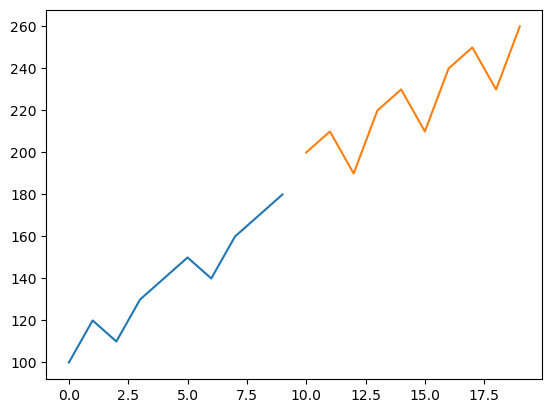

In [18]:
df.groupby('store')['sales'].plot()

store
A    Axes(0.125,0.11;0.775x0.77)
B    Axes(0.125,0.11;0.775x0.77)
Name: rolling_mean4, dtype: object

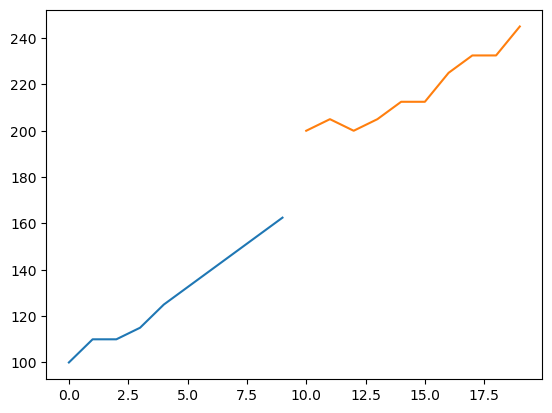

In [19]:
df.groupby('store')['rolling_mean4'].plot()

In [23]:
df['yoy']=(df['sales'] - df['sales_lag4'])/df['sales_lag4']
df

,store,week,sales,sales_lag1,sales_lag4,growth_pct_lag1,rolling_mean4,rolling_std4,rolling_sum4,expanding_sum,expanding_mean,rolling_growth_4,high_volatility,yoy
0,A,2023-01-01,100,NaN,NaN,NaN,100.0,NaN,NaN,100.0,100.000000,NaN,False,NaN
1,A,2023-01-08,120,100.0,NaN,20.000000,110.0,NaN,NaN,220.0,110.000000,NaN,False,NaN
2,A,2023-01-15,110,120.0,NaN,-8.333333,110.0,NaN,NaN,330.0,110.000000,NaN,False,NaN
3,A,2023-01-22,130,110.0,NaN,18.181818,115.0,12.909944,460.0,460.0,115.000000,NaN,False,NaN
4,A,2023-01-29,140,130.0,100.0,7.692308,125.0,12.909944,500.0,600.0,120.000000,9.385198,False,0.400000
5,A,2023-02-05,150,140.0,120.0,7.142857,132.5,17.078251,530.0,750.0,125.000000,6.170912,False,0.250000
6,A,2023-02-12,140,150.0,110.0,-6.666667,140.0,8.164966,560.0,890.0,127.142857,6.587579,False,0.272727
7,A,2023-02-19,160,140.0,130.0,14.285714,147.5,9.574271,590.0,1050.0,131.250000,5.613553,False,0.230769
8,A,2023-02-26,170,160.0,140.0,6.250000,155.0,12.909944,620.0,1220.0,135.555556,5.252976,False,0.214286
9,A,2023-03-05,180,170.0,150.0,5.882353,162.5,17.078251,650.0,1400.0,140.000000,4.937850,False,0.200000


In [24]:
df.groupby('store')['sales_lag4'].mean()

store
A    125.0
B    210.0
Name: sales_lag4, dtype: float64

In [22]:
df.groupby('store')['expanding_sum'].mean()

store
A     702.0
B    1181.0
Name: expanding_sum, dtype: float64